In [1]:
pip install EMD-signal

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import PyEMD
print(PyEMD.__version__)

1.6.4


In [3]:
import matplotlib.pyplot as plt
# 导入matplotlib的pyplot模块，用于数据可视化。
import tensorflow as tf
# 导入tensorflow库，用于深度学习模型的构建和训练
from PyEMD import EMD, EEMD, CEEMDAN
# 从pyemd库导入EMD, EEMD, CEEMDAN，用于模态分解
import pandas as pd
# 导入pandas库，用于数据处理和分析
import warnings
# 导入warnings库，用于控制警告消息
warnings.filterwarnings("ignore")

C:\Users\111\PycharmProjects\PythonProject1\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\111\PycharmProjects\PythonProject1\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\111\PycharmProjects\PythonProject1\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_han

In [4]:
gpus = tf.config.experimental.list_physical_devices(device_type='GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [5]:
# 用来正常显示中文/英文标签（保持与模板一致）
plt.rcParams['font.sans-serif'] = ['Times New Roman']
# 用来正常显示负号
plt.rcParams['axes.unicode_minus'] = False

In [6]:
df_raw_data = pd.read_csv('INDONESIA-FloodPrediction.csv')

# 确保时间列为Datetime并按时间排序
df_raw_data['Month'] = pd.to_datetime(df_raw_data['Month'])
df_raw_data = df_raw_data.sort_values('Month').reset_index(drop=True)

# 只分解目标 rx5day（推荐做法）
series_close = pd.Series(
    df_raw_data['rx5day'].astype(float).values,
    index=df_raw_data['Month']
)
# 创建一个pandas的Series对象。
# df_raw_data['rx5day'].values提取'rx5day'列的值作为Series的数据。
# index=df_raw_data['Month']设置Series的索引为时间戳（YYYY-MM）
print(series_close)

Month
1950-01-01     81.05
1950-02-01     94.92
1950-03-01     83.27
1950-04-01     94.10
1950-05-01     69.23
               ...  
2023-08-01     56.47
2023-09-01     68.16
2023-10-01     65.18
2023-11-01    100.73
2023-12-01    111.22
Length: 888, dtype: float64


In [7]:
def ceemdan_decompose(series=None, trials=100):
    # 定义CEEMDAN分解函数。
    # series: 待分解的时间序列数据。
    # trials: CEEMDAN的试验次数，用于生成噪声。

    decom = CEEMDAN()
    # 创建CEEMDAN对象。

    decom.trials = trials
    # 设置CEEMDAN对象的试验次数。

    df_ceemdan = pd.DataFrame(decom(series.values).T)
    # 对时间序列数据执行CEEMDAN分解，并将结果转置后转换为DataFrame。

    df_ceemdan.columns = ['imf' + str(i+1) for i in range(len(df_ceemdan.columns))]
    # 为DataFrame的每一列命名，表示每个内在模态函数（IMF）。

    return df_ceemdan
    # 返回分解结果的DataFrame。

In [8]:
df_ceemdan = ceemdan_decompose(series_close)
# 对series_close进行CEEMDAN分解，并返回结果的DataFrame。

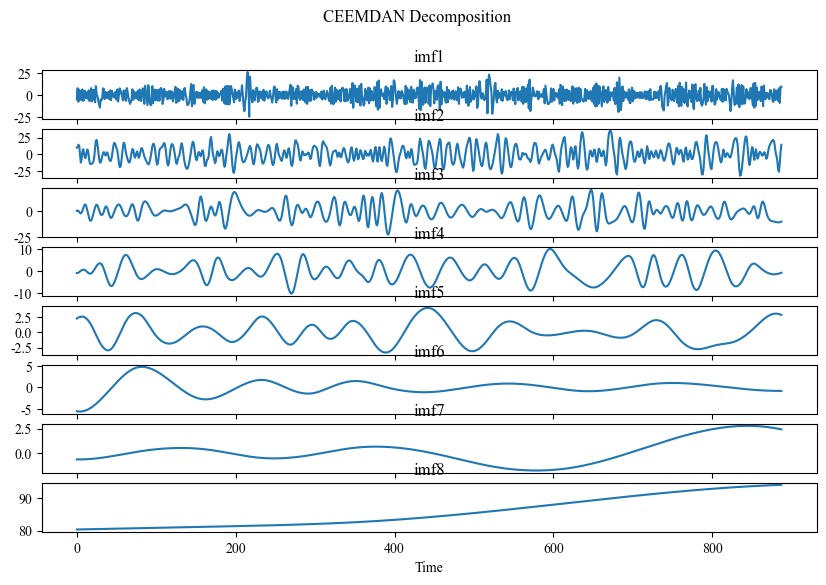

In [9]:
# 可视化VMD分解结果
fig, axs = plt.subplots(nrows=len(df_ceemdan.columns), figsize=(10, 6), sharex=True)
# 创建一个绘图对象和多个子图对象。
for i, col in enumerate(df_ceemdan.columns):
    axs[i].plot(df_ceemdan[col])
    axs[i].set_title(col)
    # 遍历每个模态并绘制在子图上。

plt.suptitle('CEEMDAN Decomposition')
# 设置图表的总标题。

plt.xlabel('Time')
# 设置x轴的标签。

plt.show()
# 显示图表。

In [10]:
print(df_ceemdan)
df_ceemdan.to_excel("CEEMDAN-INDONESIA-RX5DAY.xlsx",index=False)
#保存数据为CEEMDAN-CHINA-RX5DAY.xlsx

         imf1       imf2       imf3      imf4      imf5      imf6      imf7  \
0   -4.640205   9.892391   0.316161 -0.879265  2.218872 -5.578232 -0.595148   
1    7.788338  10.939495   0.653469 -0.881617  2.305199 -5.608243 -0.596653   
2   -7.311968  14.482998   0.353328 -0.731319  2.379615 -5.629618 -0.597657   
3    6.100417  12.588141  -0.646020 -0.472374  2.440933 -5.642194 -0.598155   
4   -4.992298  -0.442862  -1.750619 -0.162142  2.487968 -5.645810 -0.598142   
..        ...        ...        ...       ...       ...       ...       ...   
883 -6.492841 -23.465406 -10.991035 -1.240240  2.970719 -0.846124  2.489887   
884  7.638385 -25.992960 -10.963918 -1.145552  2.941506 -0.846383  2.474271   
885 -8.722063 -12.820059 -10.822537 -1.036367  2.904757 -0.846128  2.458247   
886  9.516223   4.163877 -10.567135 -0.913691  2.860736 -0.845364  2.441815   
887  9.552425  14.175706 -10.203010 -0.778526  2.809706 -0.844098  2.424978   

          imf8  
0    80.315425  
1    80.320012  
